# Workshop 3 (morning): preparing data and planning

Trainer Reference Notebook, kernel **Python (venv-ml)**.

## Cell 1: Environmental verification

- **Interpreter**:`sys.executable`must point to`.venv-ml`.
- **Nouveaux venus** : `scikit-learn`and`mlflow`, absent from the two previous environments.
- **Active file**: must contain`data/`, `energie_utils.py`and`qualite_pandas.py`.

In [1]:
# === CELLULE 1 : Vérification de l'environnement ===
import sys
from importlib.metadata import version
from pathlib import Path

print(f"Python       : {sys.version.split()[0]}")
print(f"Interpréteur : {sys.executable}")
for paquet in ("numpy", "pandas", "scikit-learn", "mlflow"):
    print(f"{paquet:<13}: {version(paquet)}")
print(f"Dossier      : {Path.cwd().name}")
print(f"Fichiers     : {sorted(p.name for p in Path('data').glob('*.csv'))}")
print(f"Modules      : {[p for p in ('energie_utils.py', 'qualite_pandas.py') if Path(p).exists()]}")

Python       : 3.12.3
Interpréteur : C:\Users\formation\python_fabric_training\.venv-ml\Scripts\python.exe
numpy        : 2.5.3
pandas       : 3.0.6
scikit-learn : 1.9.1
mlflow       : 3.16.1
Dossier      : python_fabric_training
Fichiers     : ['consommation_30jours.csv', 'sites_reference.csv']
Modules      : ['energie_utils.py', 'qualite_pandas.py']


### Demonstration: three environments, one code

**Temps 1 : `venv-data`.** Reload the notebook page (F5), then **Kernel → Change kernel → Python (venv-data)**. Execute Cells 2 and 3: scikit-learn is not found.

**Temps 2 : `venv-ml`.** **Kernel → Change kernel → Python (venv-ml)**, then re-executing both cells: everything is present.

**Time 3: return to`venv-data`.** Error ** returns**; libraries do not disappear, they have never been in this environment.

| Situation                | Result of`import sklearn` |
| ------------------------ | ---------------------------- |
| Noyau **venv-data**      | `ModuleNotFoundError`        |
| Noyau **venv-ml**        | Fonctionne                   |
| Return to **venv-data** | `ModuleNotFoundError`        |

> *Change kernel erases the variables** from the notebook. These three cells do not depend on any data: they can be played without risk.

> In Fabric**: two *Environments* may contain different libraries, and each notebook chooses its own.

## Cell 2: What each kernel sees

- **`find_spec`**: test the presence of a package **without importing it**.
- **Two nuclei to compare**:`venv-data`(Workshop 2)`venv-ml`(Workshop 3).
- **Objective**: find that scikit-learn exists only in one of the two.

In [2]:
# === CELLULE 2 : Ce que voit le noyau actif ===
import sys
from importlib.metadata import version
from importlib.util import find_spec

print("Interpréteur :", sys.executable)
for nom, paquet in (("pandas", "pandas"), ("matplotlib", "matplotlib"), ("seaborn", "seaborn"),
                    ("sklearn", "scikit-learn"), ("mlflow", "mlflow"), ("joblib", "joblib")):
    if find_spec(nom) is None:
        print(f"{nom:<11} ABSENT")
    else:
        print(f"{nom:<11} {version(paquet)}")

Interpréteur : C:\Users\formation\python_fabric_training\.venv-ml\Scripts\python.exe
pandas      3.0.6
matplotlib  3.11.2
seaborn     0.13.2
sklearn     1.9.1
mlflow      3.16.1
joblib      1.6.0


## Cell 3: Import scikit-learn: error, then success

- **Time 1**: kernel **Python (venv-data)** → import fails.
- **Time 2**: kernel **Python (venv-ml)** → import succeeds.
- **Time 3**: return to`venv-data`→ error ** returns**.

In [3]:
# === CELLULE 3 : Importer scikit-learn et MLflow ===
import pandas as pd
import sklearn
import mlflow
from sklearn.ensemble import HistGradientBoostingRegressor

print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| mlflow", mlflow.__version__)
print(HistGradientBoostingRegressor())

pandas 3.0.6 | scikit-learn 1.9.1 | mlflow 3.16.1
HistGradientBoostingRegressor()


# PART 2: PREPARING DATA

This part and the following are in the notebook`workshop3`, with the kernel **Python (venv-ml)**.

## Cell 4: Charge and clean with Workshop 2 module

- **`qualite_pandas.nettoyer`**: duplicates, dates, error codes in`NaN`(Workshop 2).
- **`merge(validate="m:1")`**: adds type and capacity of each site, without duplicate line.
- **Control**: 4,320 lines expected (6 sites × 720 hours).

In [4]:
# === CELLULE 4 : Charger et nettoyer ===
import numpy as np
import pandas as pd
import qualite_pandas as qp

brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
ref = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")

d = qp.nettoyer(brut).merge(ref[["site_id", "site_type", "capacity_mw"]], on="site_id", how="left", validate="m:1")
print(len(brut), "->", len(d), "lignes")
print(d[["timestamp", "site_id", "site_type", "capacity_mw", "conso_mw"]].head(3))
print(d["conso_mw"].isna().sum(), "valeurs manquantes")

4365 -> 4320 lignes
            timestamp       site_id   site_type  capacity_mw  conso_mw
0 2025-01-01 00:00:00  SITE_COM_001  Commercial          2.0     0.458
1 2025-01-01 01:00:00  SITE_COM_001  Commercial          2.0       NaN
2 2025-01-01 02:00:00  SITE_COM_001  Commercial          2.0     0.487
350 valeurs manquantes


## Cell 5: Target: Remove the aberrant peaks

- **Cible** : `conso_mw`, the value to be predicted.
- **Pics**: measures ** above the capacity** of the site (Workshop 2), physically impossible.
- **`conso_brute`**: retained copy for detection of anomalies (Part 5).

In [5]:
# === CELLULE 5 : Pics aberrants ===
d["conso_brute"] = d["conso_mw"]
d["pic"] = d["conso_mw"] > d["capacity_mw"]
print(d["pic"].sum(), "pics au-dessus de la capacité")
print(d.loc[d["pic"], ["site_id", "conso_mw", "capacity_mw"]].head(3))

d["conso_mw"] = d["conso_mw"].mask(d["pic"])
print(d["conso_mw"].isna().sum(), "valeurs manquantes après retrait des pics")

15 pics au-dessus de la capacité
          site_id  conso_mw  capacity_mw
200  SITE_COM_001     2.854          2.0
278  SITE_COM_001     3.416          2.0
335  SITE_COM_001     3.591          2.0
365 valeurs manquantes après retrait des pics


## Cellule 6 : Variables de calendrier

- **`.dt`**: time and weekday extract from`timestamp`.
- **`weekend`**: 1 if Saturday or Sunday, otherwise 0.
- **Why**: Site profiles change according to time and type of day (Workshop 2).

In [6]:
# === CELLULE 6 : Variables de calendrier ===
d["heure"] = d["timestamp"].dt.hour
d["jour_sem"] = d["timestamp"].dt.dayofweek
d["weekend"] = (d["jour_sem"] >= 5).astype(int)

print(d[["timestamp", "heure", "jour_sem", "weekend"]].iloc[[0, 30, 130]])
d["taux"] = d["conso_mw"] / d["capacity_mw"]
print(d.pivot_table(index="site_type", columns="weekend", values="taux", aggfunc="mean").round(3))

              timestamp  heure  jour_sem  weekend
0   2025-01-01 00:00:00      0         2        0
30  2025-01-02 06:00:00      6         3        0
130 2025-01-06 10:00:00     10         0        0
weekend          0      1
site_type                
Commercial   0.448  0.316
Industrie    0.506  0.303
Residentiel  0.465  0.534


## Cell 7: The principle of scikit-learn:`fit`, `predict`, `score`

- **`X`**: table of **Explanatory variables** (2 dimensions, here only one column).
- **`y`**: Target** (1 dimension).
- **Trois verbes** : `fit` (apprendre), `predict`(provide),`score`(measure) identical for **all** models.

In [7]:
# === CELLULE 7 : L'interface commune ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

site = d[(d["site_id"] == "SITE_COM_001") & d["conso_mw"].notna()]
X, y = site[["heure"]], site["conso_mw"]

for modele in (LinearRegression(), RandomForestRegressor(n_estimators=50, random_state=0)):
    modele.fit(X, y)
    prevu = modele.predict(pd.DataFrame({"heure": [3, 14]}))
    print(f"{type(modele).__name__:<22} 3 h / 14 h : {prevu.round(2)}   R² sur ces données : {modele.score(X, y):.2f}")
print("Coefficient appris (linéaire) :", round(LinearRegression().fit(X, y).coef_[0], 4))

LinearRegression       3 h / 14 h : [0.7  0.87]   R² sur ces données : 0.07


RandomForestRegressor  3 h / 14 h : [0.46 1.23]   R² sur ces données : 0.88
Coefficient appris (linéaire) : 0.0158


## Cell 8: Lagged values: the previous and last week

- **Regular glass**:`shift(24)`is "24 hours before" **only** if lines are one hour apart.
- **`groupby("site_id")`**: the time difference must never** cross from site to site.
- **Horizon**: These variables are expected to be ** the next day** (at least 24 hours in advance).

In [8]:
# === CELLULE 8 : Valeurs décalées ===
ecarts = d.groupby("site_id")["timestamp"].diff().dropna()
print("Écarts entre lignes :", ecarts.value_counts().to_dict())

g = d.groupby("site_id")["conso_mw"]
d["lag_24"] = g.shift(24)
d["lag_168"] = g.shift(168)

site = d[d["site_id"] == "SITE_COM_001"]
print(site[["timestamp", "conso_mw", "lag_24", "lag_168"]].iloc[[0, 24, 168, 192]])
print(d[["lag_24", "lag_168"]].isna().sum().to_dict())

Écarts entre lignes : {Timedelta('0 days 01:00:00'): 4314}


     timestamp  conso_mw  lag_24  lag_168
0   2025-01-01     0.458     NaN      NaN
24  2025-01-02     0.519   0.458      NaN
168 2025-01-08       NaN   0.461    0.458
192 2025-01-09     0.496     NaN    0.519
{'lag_24': 498, 'lag_168': 1300}


## Cellule 9 : Moyenne glissante sans regarder l'avenir

- **`rolling(24)`**: average of 24 consecutive values.
- **`shift(24)`before`rolling`** : window ends **24 h before** measurement ; at the moment of the forecast (the day before), all these values are known.
- **Verification**: Recalculate a hand value.

In [9]:
# === CELLULE 9 : Moyenne glissante ===
d["moy_veille"] = g.transform(lambda s: s.shift(24).rolling(24, min_periods=12).mean())

i = 500
a_la_main = d.loc[i - 47:i - 24, "conso_mw"].mean()
print("Ligne", i, d.loc[i, "site_id"], d.loc[i, "timestamp"])
print("À la main :", round(a_la_main, 4), "| colonne moy_veille :", round(d.loc[i, "moy_veille"], 4))
print(d["moy_veille"].isna().sum(), "valeurs absentes")

Ligne 500 SITE_COM_001 2025-01-21 20:00:00
À la main : 0.8411 | colonne moy_veille : 0.8411
217 valeurs absentes


## Cell 10: Time cut: past to learn, future to test

- **Never random**: the **future** is expected, so we test the future.
- **Coupure**: training until 23 January, test from 24 to 30.
- **7 days left**: not yet`lag_168`.

In [10]:
# === CELLULE 10 : Découpage temporel ===
VARIABLES = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
COUPURE = pd.Timestamp("2025-01-24")

utile = d[(d["timestamp"] >= "2025-01-08") & d["conso_mw"].notna()]
train = utile[utile["timestamp"] < COUPURE]
test = utile[utile["timestamp"] >= COUPURE].dropna(subset=["lag_24", "lag_168"])

print("Entraînement :", len(train), "lignes,", train["timestamp"].min().date(), "->", train["timestamp"].max().date())
print("Test         :", len(test), "lignes,", test["timestamp"].min().date(), "->", test["timestamp"].max().date())
print("Manquants dans train :", train[VARIABLES].isna().sum()[lambda s: s > 0].to_dict())

Entraînement : 2099 lignes, 2025-01-08 -> 2025-01-23
Test         : 799 lignes, 2025-01-24 -> 2025-01-30
Manquants dans train : {'lag_24': 188, 'lag_168': 194}


## Cell 11: Correlation with Target

- **`corr()`**: linear correlation of each variable with`conso_mw`.
- **Limit**: measures only the **linear** link, not the utility of a model.
- **Reading**: close to 1 = follows the target; close to 0 = no linear link.

In [11]:
# === CELLULE 11 : Corrélations ===
print(train[VARIABLES + ["conso_mw"]].corr()["conso_mw"].drop("conso_mw").round(2))

heure          0.09
weekend       -0.18
capacity_mw    0.86
lag_24         0.94
lag_168        0.99
moy_veille     0.83
Name: conso_mw, dtype: float64


# PART 3: PREVENT CONSUMPTION (REGRESSION)

## Cell 12: The references to beat

- **Gold rule**: a model has value only if it beats a single **reference**.
- **Three references**: same time the day before, same time last week, average site.
- **Metrics**: **MAE** (average error in MW), **RMSE** (penalizes large deviations), **R2** (share of variation explained).

In [12]:
# === CELLULE 12 : Références ===
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def evaluer(y_vrai, y_pred):
    return {"MAE": mean_absolute_error(y_vrai, y_pred),
            "RMSE": root_mean_squared_error(y_vrai, y_pred),
            "R2": r2_score(y_vrai, y_pred)}

moyenne_site = train.groupby("site_id")["conso_mw"].mean()
references = {
    "même heure la veille": test["lag_24"],
    "même heure la semaine dernière": test["lag_168"],
    "moyenne du site": test["site_id"].map(moyenne_site),
}
resultats = {nom: evaluer(test["conso_mw"], p) for nom, p in references.items()}
print(pd.DataFrame(resultats).T.round(3))

                                  MAE   RMSE     R2
même heure la veille            0.157  0.309  0.854
même heure la semaine dernière  0.066  0.105  0.983
moyenne du site                 0.323  0.417  0.734


## Cell 13: First regression:`LinearRegression`

- **Linear model**: a weighted sum of variables.
- ** Missing values**: refused; they are replaced by the **median training** (never test).
- **`coef_`**: the weight learned for each variable.

In [13]:
# === CELLULE 13 : Régression linéaire ===
from sklearn.linear_model import LinearRegression

mediane = train[VARIABLES].median()
lin = LinearRegression().fit(train[VARIABLES].fillna(mediane), train["conso_mw"])
p_lin = lin.predict(test[VARIABLES].fillna(mediane))

resultats["régression linéaire"] = evaluer(test["conso_mw"], p_lin)
print({v: round(float(c), 3) for v, c in zip(VARIABLES, lin.coef_)})
print(pd.Series(resultats["régression linéaire"]).round(3).to_dict())

{'heure': 0.003, 'weekend': -0.139, 'capacity_mw': 0.198, 'lag_24': 0.296, 'lag_168': 0.542, 'moy_veille': -0.212}
{'MAE': 0.103, 'RMSE': 0.143, 'R2': 0.969}


## Cell 14: Tree-based models: random forest and gradient boosting

- **`RandomForestRegressor`**: average of many decision trees.
- **`HistGradientBoostingRegressor`**: trees built one after the other, each correcting the previous one; accept the`NaN` **sans imputation**.
- **`random_state`**: makes the result **reproducible**.

In [14]:
# === CELLULE 14 : Forêt et gradient boosting ===
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

foret = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
foret.fit(train[VARIABLES].fillna(mediane), train["conso_mw"])
hgb = HistGradientBoostingRegressor(random_state=0).fit(train[VARIABLES], train["conso_mw"])

p_foret = foret.predict(test[VARIABLES].fillna(mediane))
p_hgb = hgb.predict(test[VARIABLES])
resultats["forêt aléatoire"] = evaluer(test["conso_mw"], p_foret)
resultats["gradient boosting"] = evaluer(test["conso_mw"], p_hgb)
print(pd.DataFrame(resultats).T.loc[["forêt aléatoire", "gradient boosting"]].round(3))

                     MAE   RMSE     R2
forêt aléatoire    0.055  0.083  0.989
gradient boosting  0.059  0.090  0.988


## Cell 15: Compare all models

- **Same test set** for all: figures are comparable.
- **Tri by MAE**: the smallest average error first.
- **Use test**: the booster gradient even predicts **without history** (delayed values absent).

In [15]:
# === CELLULE 15 : Tableau comparatif ===
tableau = pd.DataFrame(resultats).T.sort_values("MAE").round(3)
print(tableau)

ligne = test.iloc[[0]][VARIABLES].assign(lag_24=np.nan, lag_168=np.nan, moy_veille=np.nan)
print("\nSans aucun historique -> prévision :", round(float(hgb.predict(ligne)[0]), 3), "MW | réel :", round(float(test.iloc[0]["conso_mw"]), 3), "MW")

                                  MAE   RMSE     R2
forêt aléatoire                 0.055  0.083  0.989
gradient boosting               0.059  0.090  0.988
même heure la semaine dernière  0.066  0.105  0.983
régression linéaire             0.103  0.143  0.969
même heure la veille            0.157  0.309  0.854
moyenne du site                 0.323  0.417  0.734

Sans aucun historique -> prévision : 0.593 MW | réel : 0.491 MW


## Cell 16: The ceiling: the noise that no model can predict

- **Noise**: Each measure varies at random by ±10% around its profile (simulated data, Workshop 1).
- **Best possible forecast**: the average of each combination (site, time, type of day).
- **Question**: Are our models already close to this ceiling?

In [16]:
# === CELLULE 16 : Erreur incompressible ===
profil = train.groupby(["site_id", "heure", "weekend"])["conso_mw"].mean()
p_profil = test.set_index(["site_id", "heure", "weekend"]).index.map(profil)

r = evaluer(test["conso_mw"], p_profil)
print({k: round(v, 3) for k, v in r.items()})
print("Niveau moyen de la consommation :", round(test["conso_mw"].mean(), 3), "MW")
print("MAE / niveau moyen :", f"{r['MAE'] / test['conso_mw'].mean():.1%}")

{'MAE': 0.053, 'RMSE': 0.08, 'R2': 0.99}
Niveau moyen de la consommation : 0.978 MW
MAE / niveau moyen : 5.4%


## Cellule 17 : `Pipeline`and`ColumnTransformer`: pretreatment with the model

- **Problem**: imputation, encoding, scaling and model are separated; We forget a stage in production.
- **`ColumnTransformer`**: different processing by group of columns (encoded text, imputed numbers then scaled).
- **`Pipeline`**: one object, one object`fit`only one`predict`.

In [17]:
# === CELLULE 17 : Pipeline complet ===
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeriques = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
prep = ColumnTransformer([
    ("site", OneHotEncoder(handle_unknown="ignore"), ["site_id"]),
    ("nombres", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeriques),
])
pipe_lin = Pipeline([("prep", prep), ("modele", LinearRegression())])
pipe_lin.fit(train[["site_id"] + numeriques], train["conso_mw"])

p = pipe_lin.predict(test[["site_id"] + numeriques])
resultats["linéaire + pipeline"] = evaluer(test["conso_mw"], p)
print(list(pipe_lin.named_steps))
print(list(pipe_lin[:-1].get_feature_names_out())[:8], "...")
print(pd.Series(resultats["linéaire + pipeline"]).round(3).to_dict())

['prep', 'modele']
['site__site_id_SITE_COM_001', 'site__site_id_SITE_COM_002', 'site__site_id_SITE_IND_001', 'site__site_id_SITE_IND_002', 'site__site_id_SITE_RES_001', 'site__site_id_SITE_RES_002', 'nombres__heure', 'nombres__weekend'] ...
{'MAE': 0.103, 'RMSE': 0.143, 'R2': 0.969}


## Cell 18: Final pipeline: native categories and gradient boosting

- **`OrdinalEncoder`** : transforme `site_id` en entier ; `HistGradientBoostingRegressor`treats it as **category** (`categorical_features=[0]`).
- **Site inconnu** : `unknown_value=np.nan`Avoid an error if a new site appears.
- **This pipeline** will be **safeguarded** in Part 7.

In [18]:
# === CELLULE 18 : Pipeline gradient boosting ===
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

COLONNES = ["site_id"] + VARIABLES
prep_hgb = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), ["site_id"]),
    remainder="passthrough",
)
pipe_hgb = make_pipeline(prep_hgb, HistGradientBoostingRegressor(categorical_features=[0], random_state=0))
pipe_hgb.fit(train[COLONNES], train["conso_mw"])

p_pipe = pipe_hgb.predict(test[COLONNES])
resultats["gradient boosting + pipeline"] = evaluer(test["conso_mw"], p_pipe)
print(pd.Series(resultats["gradient boosting + pipeline"]).round(3).to_dict())

{'MAE': 0.058, 'RMSE': 0.09, 'R2': 0.988}


## Cell 19: Forecast Against Reality on the Test Week

- **A site**,`SITE_IND_001`, on the 7 days test.
- **Three curves**: real, gradient boosting, reference "last week".
- **`fig.savefig`**: PNG is recorded in`out/`.

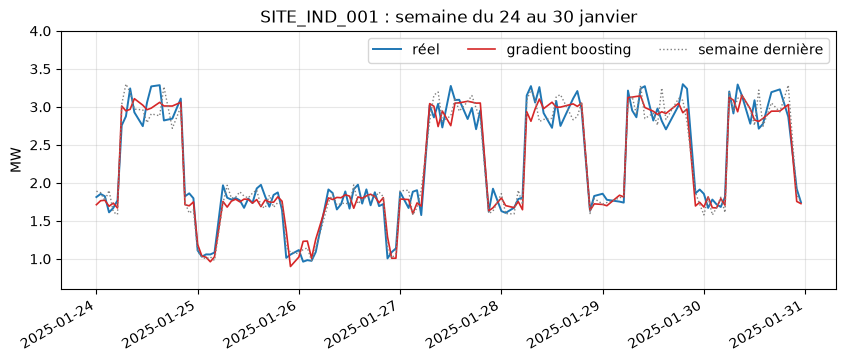

In [19]:
# === CELLULE 19 : Figure prévision ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
t = test.assign(prevu=p_pipe)
s = t[t["site_id"] == "SITE_IND_001"]

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(s["timestamp"], s["conso_mw"], color="#1f77b4", linewidth=1.4, label="réel")
ax.plot(s["timestamp"], s["prevu"], color="#d62728", linewidth=1.2, label="gradient boosting")
ax.plot(s["timestamp"], s["lag_168"], color="#7f7f7f", linewidth=1, linestyle=":", label="semaine dernière")
ax.set_title("SITE_IND_001 : semaine du 24 au 30 janvier")
ax.set_ylabel("MW")
ax.set_ylim(0.6, 4.0)
ax.legend(loc="upper right", ncol=3)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.savefig("out/fig_prevision.png", dpi=110, bbox_inches="tight")

## Cell 20: Site-by-site error

- **Absolute MAE**: MW dominated by large sites.
- **Rative MAE**: Average site consumption, comparable between sites.
- **Business decision**: useful accuracy depends on the size of the site.

In [20]:
# === CELLULE 20 : Erreur par site ===
t = test.assign(prevu=p_pipe, erreur=lambda x: (x["conso_mw"] - x["prevu"]).abs())
par_site = t.groupby("site_id").agg(niveau_mw=("conso_mw", "mean"), mae_mw=("erreur", "mean"))
par_site["mae_relative"] = (par_site["mae_mw"] / par_site["niveau_mw"]).map("{:.1%}".format)
print(par_site.round(3))

              niveau_mw  mae_mw mae_relative
site_id                                     
SITE_COM_001      0.823   0.047         5.8%
SITE_COM_002      0.603   0.029         4.9%
SITE_IND_001      2.206   0.140         6.3%
SITE_IND_002      1.583   0.093         5.9%
SITE_RES_001      0.389   0.025         6.4%
SITE_RES_002      0.295   0.017         5.9%


## Cell 21: Save preparation in a module

- **Objective**: Replay the preparation this afternoon without copying cells.
- **Content**: loading, variables, cutting, evaluation, final pipeline.
- **`prevision_conso.py`**: will be completed at the end of the day.

In [21]:
# === CELLULE 21 : prevision_conso.py ===
from pathlib import Path

Path("prevision_conso.py").write_text('''"""prevision_conso.py — Préparation, évaluation et modèle de prévision (Workshop 3)."""
import numpy as np
import pandas as pd
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder

import qualite_pandas as qp

VARIABLES = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
COLONNES = ["site_id"] + VARIABLES
DEBUT_UTILE = pd.Timestamp("2025-01-08")
COUPURE = pd.Timestamp("2025-01-24")


def charger_propre(mesures="data/consommation_30jours.csv", reference="data/sites_reference.csv"):
    """Mesures nettoyées (Workshop 2), avec type et capacité des sites."""
    brut = pd.read_csv(mesures, encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
    ref = pd.read_csv(reference, encoding="utf-8-sig")[["site_id", "site_type", "capacity_mw"]]
    return qp.nettoyer(brut).merge(ref, on="site_id", how="left", validate="m:1")


def ajouter_variables(d):
    """Cible sans pics, variables de calendrier, valeurs décalées, moyenne glissante."""
    d = d.copy()
    d["conso_brute"] = d["conso_mw"]
    d["pic"] = d["conso_mw"] > d["capacity_mw"]
    d["conso_mw"] = d["conso_mw"].mask(d["pic"])
    d["heure"] = d["timestamp"].dt.hour
    d["jour_sem"] = d["timestamp"].dt.dayofweek
    d["weekend"] = (d["jour_sem"] >= 5).astype(int)
    d["taux"] = d["conso_mw"] / d["capacity_mw"]
    g = d.groupby("site_id")["conso_mw"]
    d["lag_24"] = g.shift(24)
    d["lag_168"] = g.shift(168)
    d["moy_veille"] = g.transform(lambda s: s.shift(24).rolling(24, min_periods=12).mean())
    return d


def preparer(**chemins):
    return ajouter_variables(charger_propre(**chemins))


def decouper(d, coupure=COUPURE):
    """Passé pour apprendre, futur (lags complets) pour tester."""
    utile = d[(d["timestamp"] >= DEBUT_UTILE) & d["conso_mw"].notna()]
    return (utile[utile["timestamp"] < coupure],
            utile[utile["timestamp"] >= coupure].dropna(subset=["lag_24", "lag_168"]))


def evaluer(y_vrai, y_pred):
    return {"MAE": mean_absolute_error(y_vrai, y_pred),
            "RMSE": root_mean_squared_error(y_vrai, y_pred),
            "R2": r2_score(y_vrai, y_pred)}


def construire_modele(**params):
    """Pipeline final : site encodé comme catégorie + gradient boosting."""
    prep = make_column_transformer(
        (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), ["site_id"]),
        remainder="passthrough",
    )
    return make_pipeline(prep, HistGradientBoostingRegressor(categorical_features=[0], random_state=0, **params))
''', encoding="utf-8")
print(Path("prevision_conso.py").stat().st_size, "octets écrits")

2752 octets écrits


## Cell 22: Verify that the module reproduces the preparation

- **`invalidate_caches`**: the file was created in the session.
- **`assert_frame_equal`** : compare column by column with the`d`built by hand.
- **Expected result**: same sizes and errors as in Cell 18.

In [22]:
# === CELLULE 22 : Contrôle du module ===
import importlib
importlib.invalidate_caches()

import prevision_conso as pc

d2 = pc.preparer()
colonnes = ["timestamp", "site_id", "conso_mw", "heure", "weekend", "lag_24", "lag_168", "moy_veille"]
pd.testing.assert_frame_equal(d2[colonnes], d[colonnes])

tr2, te2 = pc.decouper(d2)
modele = pc.construire_modele().fit(tr2[pc.COLONNES], tr2["conso_mw"])
mae = pc.evaluer(te2["conso_mw"], modele.predict(te2[pc.COLONNES]))["MAE"]
print(len(tr2), len(te2), "lignes | MAE :", round(mae, 3), "| identique à la Cellule 18 :", round(mae, 6) == round(resultats["gradient boosting + pipeline"]["MAE"], 6))

2099 799 lignes | MAE : 0.058 | identique à la Cellule 18 : True
